<a href="https://colab.research.google.com/github/emon4075/PyTorch-For-Deep-Learning/blob/master/PyTorch_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [37]:
# Import the necessary libraries for building neural networks in PyTorch, data manipulation with pandas,
# plotting with matplotlib, and dataset loading/splitting with scikit-learn.
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split


# Define the Model Class

In [38]:
class Model(nn.Module):
  # Define a simple neural network model.
  def __init__(self, feature_number=4):
    super().__init__()

    # Define the sequential layers of the neural network.
    self.model = nn.Sequential(
        nn.Linear(feature_number, 8), # First linear layer with input_features to 8 output features
        nn.ReLU(), # ReLU activation function
        nn.Linear(8, 9), # Second linear layer from 8 to 9 features
        nn.ReLU(), # ReLU activation function
        nn.Linear(9, 3) # Output linear layer from 9 to 3 features
    )

  # Define the forward pass of the model.
  def forward(self, input):
    return self.model(input)


In [39]:
# Set a random seed for reproducibility of results.
torch.manual_seed(42)
# Instantiate the defined Model class.
model = Model()


# Process the Data

In [40]:
# Load the Iris dataset from scikit-learn.
data = load_iris()
# Extract the features (petal length, petal width, sepal length, sepal width).
X = data.data
# Extract the target labels (species of iris flower).
y = data.target


# Train Test Split

In [41]:
# Split the dataset into training and testing sets.
# X_train, y_train will be used for training the model.
# X_test, y_test will be used for evaluating the model.
# test_size=0.2 means 20% of the data will be used for testing.
# random_state=42 ensures reproducibility of the split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Features to Float Tensors

In [42]:
# Convert training features to PyTorch FloatTensors.
X_train = torch.FloatTensor(X_train)
# Convert testing features to PyTorch FloatTensors.
X_test = torch.FloatTensor(X_test)


# Labels to Long Tensors

In [43]:
# Convert training labels to PyTorch LongTensors (for CrossEntropyLoss).
y_train = torch.LongTensor(y_train)
# Convert testing labels to PyTorch LongTensors.
y_test = torch.LongTensor(y_test)


# Define Parameters

In [44]:
# Print the model's parameters, which include weights and biases of the linear layers.
print(model.parameters)


<bound method Module.parameters of Model(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=9, bias=True)
    (3): ReLU()
    (4): Linear(in_features=9, out_features=3, bias=True)
  )
)>


In [45]:
# Define the loss function: CrossEntropyLoss is suitable for multi-class classification.
criterion = nn.CrossEntropyLoss()
# Define the optimizer: Adam with a learning rate of 0.1.
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)


# Train the Model

In [46]:
# Set the number of training epochs.
epochs = 101
# Initialize an empty list to store loss values.
losses = []

for each in range(epochs):
  # Perform a forward pass to get predictions from the model.
  y_pred = model.forward(X_train)

  # Calculate the loss between predictions and actual labels.
  loss = criterion(y_pred, y_train)
  # Store the loss value (detached from the computation graph).
  losses.append(loss.detach().numpy())

  # Print the loss every 10 epochs.
  if each % 10 == 0:
    print(f'Epoch {each} & Loss -> {loss}')

  # Clear previous gradients.
  optimizer.zero_grad()
  # Perform backpropagation to compute gradients.
  loss.backward()
  # Update model parameters using the optimizer.
  optimizer.step()


Epoch 0 & Loss -> 1.0846974849700928
Epoch 10 & Loss -> 0.4929122030735016
Epoch 20 & Loss -> 0.22069598734378815
Epoch 30 & Loss -> 0.08433595299720764
Epoch 40 & Loss -> 0.0667315274477005
Epoch 50 & Loss -> 0.06453204900026321
Epoch 60 & Loss -> 0.06003931537270546
Epoch 70 & Loss -> 0.05728408321738243
Epoch 80 & Loss -> 0.05500824749469757
Epoch 90 & Loss -> 0.05377717688679695
Epoch 100 & Loss -> 0.05286191776394844


# Loss Over Epochs

Text(0, 0.5, 'Losses')

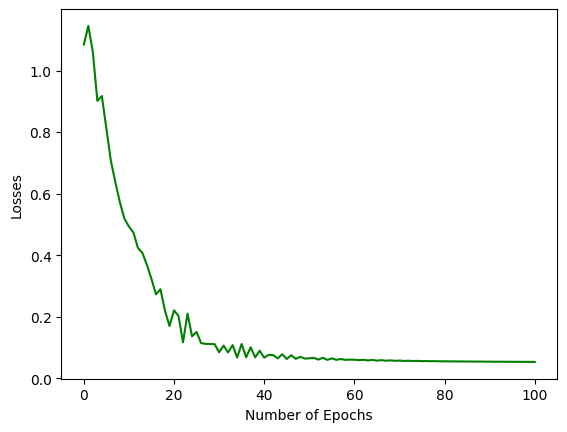

In [47]:
# Plot the loss values over the training epochs.
plt.plot(range(epochs), losses, color='green')
# Label the x-axis.
plt.xlabel("Number of Epochs")
# Label the y-axis.
plt.ylabel("Losses")
# Display the plot.
plt.show()


# Evaluate the Model

In [48]:
with torch.no_grad(): # Disable gradient calculation for evaluation, saving memory and computation.
  y_eval = model.forward(X_test) # Make predictions on the test set.
  loss = criterion(y_eval, y_test) # Calculate the loss on the test set.

print(loss) # Print the final loss on the test set.


tensor(0.0458)


In [49]:
correct = 0 # Initialize a counter for correct predictions.
with torch.no_grad(): # Disable gradient calculation for evaluation.
  for i, data in enumerate(X_test):
    y_pred = model.forward(data) # Get prediction for a single test data point.
    # Print prediction details: index, input data, predicted label, and actual label.
    print(f'{i+1}) {data} -> Predicted Label -> {y_pred.argmax()}, -> Actual Label -> {y_test[i]}')

    if y_pred.argmax() == y_test[i]: # Check if the predicted label matches the actual label.
      correct += 1 # Increment correct prediction count.

  # Print the total number of correct predictions and the total test samples.
  print(f'Number of Correct Predictions: {correct}/{len(X_test)}')


1) tensor([6.1000, 2.8000, 4.7000, 1.2000]) -> Predicted Label -> 1, -> Actual Label -> 1
2) tensor([5.7000, 3.8000, 1.7000, 0.3000]) -> Predicted Label -> 0, -> Actual Label -> 0
3) tensor([7.7000, 2.6000, 6.9000, 2.3000]) -> Predicted Label -> 2, -> Actual Label -> 2
4) tensor([6.0000, 2.9000, 4.5000, 1.5000]) -> Predicted Label -> 1, -> Actual Label -> 1
5) tensor([6.8000, 2.8000, 4.8000, 1.4000]) -> Predicted Label -> 1, -> Actual Label -> 1
6) tensor([5.4000, 3.4000, 1.5000, 0.4000]) -> Predicted Label -> 0, -> Actual Label -> 0
7) tensor([5.6000, 2.9000, 3.6000, 1.3000]) -> Predicted Label -> 1, -> Actual Label -> 1
8) tensor([6.9000, 3.1000, 5.1000, 2.3000]) -> Predicted Label -> 2, -> Actual Label -> 2
9) tensor([6.2000, 2.2000, 4.5000, 1.5000]) -> Predicted Label -> 1, -> Actual Label -> 1
10) tensor([5.8000, 2.7000, 3.9000, 1.2000]) -> Predicted Label -> 1, -> Actual Label -> 1
11) tensor([6.5000, 3.2000, 5.1000, 2.0000]) -> Predicted Label -> 2, -> Actual Label -> 2
12) tens

# Prediction on New Data

In [50]:
# Define new data for prediction. The last element is the true label (Virginica).
data_list = [5.9, 3.0, 5.1, 1.8, 2]
# Extract the feature data from the list.
feature_data = data_list[:4]
# Print the extracted feature data.
print(f'New Feature Data: {feature_data}')
# Print the true label for the new feature data.
print(f'New Feature True Label: {data_list[-1]}')


New Feature Data: [5.9, 3.0, 5.1, 1.8]
New Feature True Label: 2


In [51]:
# Convert the feature data list into a PyTorch tensor.
feature_data_tensor = torch.tensor(feature_data)

with torch.no_grad(): # Disable gradient calculation as we are only making a prediction.
  # Make a prediction with the model and print the raw output (logits).
  print(model(feature_data_tensor))
  # Print the predicted label by finding the index of the maximum logit.
  print(f'Predicted Label: {(model(feature_data_tensor)).argmax()}')


tensor([-20.4417,   4.8304,   7.4323])
Predicted Label: 2
